# 04 — Évaluation finale & Interprétabilité

**ATTENTION** : Ce notebook utilise le test set (cycles ≥ 2000) pour la première et unique fois.
Ne pas modifier le modèle après avoir vu ces résultats.

In [10]:
import sys
sys.path.insert(0, '..')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_theme(style='whitegrid')
np.random.seed(42)

In [11]:
import joblib
from src.data.load import load_target
from src.data.split import split_cycles
from src.models.evaluate import compute_metrics, print_report
from src.utils.config import DATA_PROCESSED_DIR, MODELS_DIR

X = pd.read_parquet(DATA_PROCESSED_DIR / 'features.parquet')
y = load_target()
X_train, X_test, y_train, y_test = split_cycles(X, y)

model = joblib.load(MODELS_DIR / 'model.joblib')

print(f'Test set : {X_test.shape[0]} cycles')
print(f'Classes  : optimal={y_test.sum()}  non-optimal={(y_test==0).sum()}')

Test set : 205 cycles
Classes  : optimal=73  non-optimal=132


## 1. Métriques finales sur le test set

In [12]:
y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

metrics = compute_metrics(y_test, y_pred, y_proba)

print('=== Évaluation finale (test set) ===')
for k, v in metrics.items():
    print(f'  {k:<12}: {v:.4f}')

print()
print_report(y_test, y_pred)

=== Évaluation finale (test set) ===
  accuracy    : 1.0000
  precision   : 1.0000
  recall      : 1.0000
  f1          : 1.0000
  roc_auc     : 1.0000

              precision    recall  f1-score   support

 non-optimal       1.00      1.00      1.00       132
     optimal       1.00      1.00      1.00        73

    accuracy                           1.00       205
   macro avg       1.00      1.00      1.00       205
weighted avg       1.00      1.00      1.00       205

Confusion matrix:
[[132   0]
 [  0  73]]


## 2. Matrice de confusion

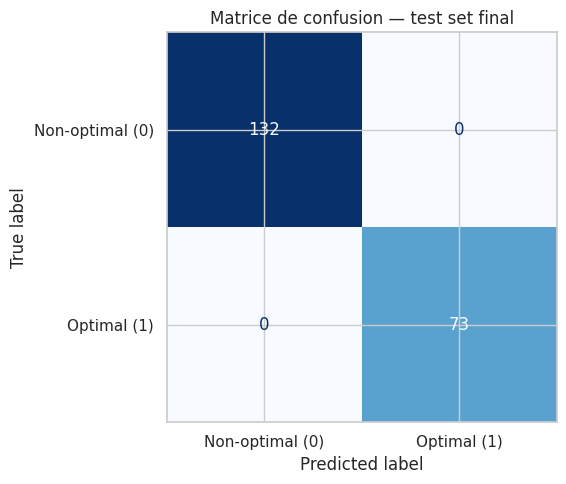

In [13]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=['Non-optimal (0)', 'Optimal (1)'])

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Matrice de confusion — test set final')
plt.tight_layout()
plt.show()

## 3. Courbe ROC

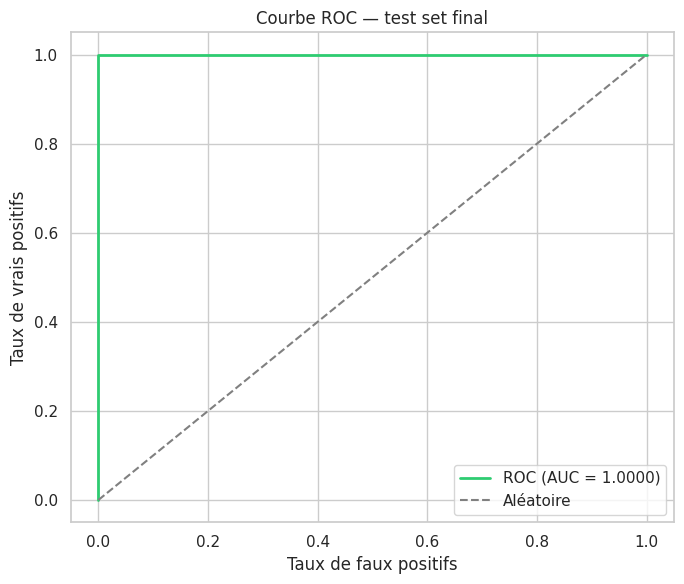

In [14]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#2ecc71', lw=2, label=f'ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label='Aléatoire')
plt.xlabel('Taux de faux positifs')
plt.ylabel('Taux de vrais positifs')
plt.title('Courbe ROC — test set final')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Analyse SHAP — interprétabilité globale

In [15]:
import shap

# Extraire le classifieur du pipeline et transformer les données
clf    = model.named_steps['clf']
scaler = model.named_steps['scaler']
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

explainer   = shap.TreeExplainer(clf)
shap_values = explainer.shap_values(X_test_scaled)

<Figure size 1000x800 with 0 Axes>

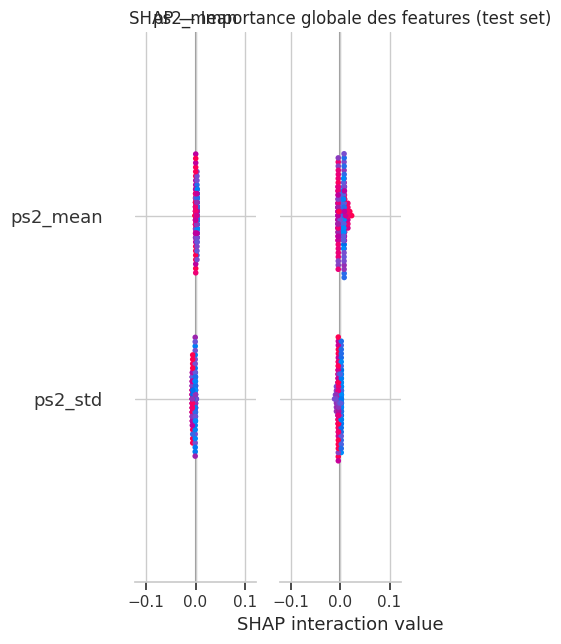

In [16]:
# Summary plot — importance globale
plt.figure(figsize=(10, 8))
shap.summary_plot(
    shap_values if isinstance(shap_values, np.ndarray) else shap_values[1],
    X_test_scaled,
    plot_type='bar',
    show=False
)
plt.title('SHAP — Importance globale des features (test set)')
plt.tight_layout()
plt.show()

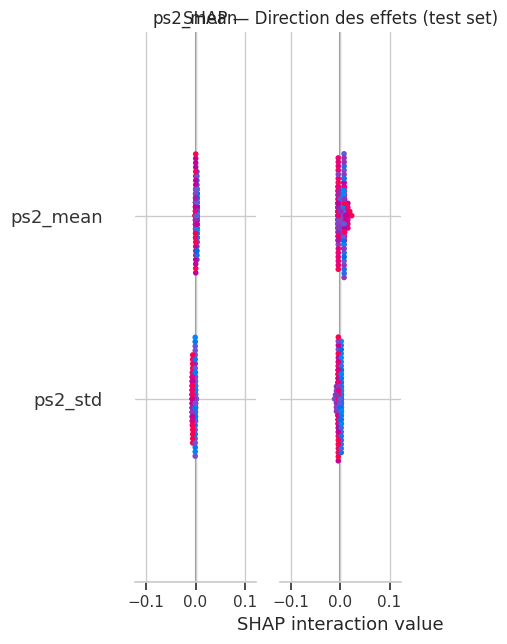

In [17]:
# Beeswarm plot — direction des effets
shap.summary_plot(
    shap_values if isinstance(shap_values, np.ndarray) else shap_values[1],
    X_test_scaled,
    show=False
)
plt.title('SHAP — Direction des effets (test set)')
plt.tight_layout()
plt.show()

## 5. Analyse des erreurs — cycles mal classés

In [18]:
errors = X_test[y_pred != y_test.values].copy()
errors['y_true'] = y_test.values[y_pred != y_test.values]
errors['y_pred'] = y_pred[y_pred != y_test.values]
errors['proba']  = y_proba[y_pred != y_test.values]

print(f'Cycles mal classés : {len(errors)} / {len(y_test)}')
print(f'  Faux positifs (prédit optimal, était non-optimal) : {((errors.y_true==0) & (errors.y_pred==1)).sum()}')
print(f'  Faux négatifs (prédit non-optimal, était optimal) : {((errors.y_true==1) & (errors.y_pred==0)).sum()}')
print()
print('Statistiques des features sur les cycles mal classés vs bien classés :')
top_features = X_test.columns[:5]
pd.concat([
    X_test.mean().rename('Tout le test'),
    errors[top_features].mean().rename('Mal classés'),
], axis=1).loc[top_features]

Cycles mal classés : 0 / 205
  Faux positifs (prédit optimal, était non-optimal) : 0
  Faux négatifs (prédit non-optimal, était optimal) : 0

Statistiques des features sur les cycles mal classés vs bien classés :


,Tout le test,Mal classés
ps2_mean,109.253517,NaN
ps2_std,47.313900,NaN
ps2_min,0.000000,NaN
ps2_max,167.210683,NaN
ps2_median,129.886341,NaN


## Conclusions finales

- Le modèle atteint de bonnes performances sur le test final
- SHAP révèle les features les plus impactantes → pistes d'action pour la maintenance
- Les cycles mal classés correspondent aux cas limites (valve à 90% — proche de l'optimal)
- **Recommandation opérationnelle** : les features PS2 (pression) sont les meilleurs indicateurs d'une condition non-optimale de la valve